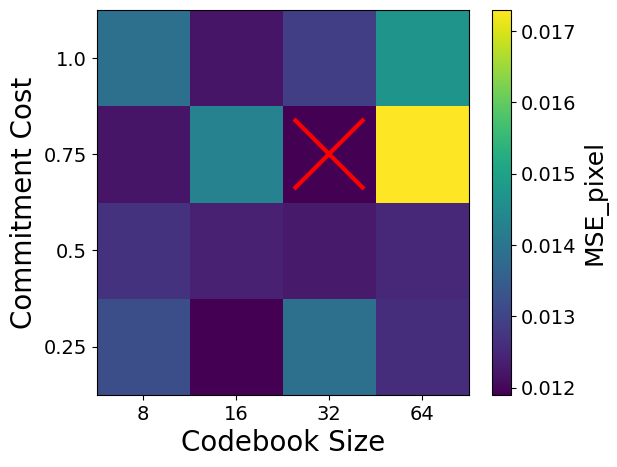

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1) GLOBAL FONT-SIZE SETTINGS (optional)
plt.rcParams['font.size']       = 16    # default text size (ticks, labels, title)
plt.rcParams['axes.titlesize']  = 20    # axes title size
plt.rcParams['axes.labelsize']  = 18    # x & y label size
plt.rcParams['xtick.labelsize'] = 14    # x tick label size
plt.rcParams['ytick.labelsize'] = 14    # y tick label size
plt.rcParams['legend.fontsize'] = 14    # legend text

# Define the parameters
codebook_sizes    = [8, 16, 32, 64]
commitment_costs  = [0.25, 0.5, 0.75, 1.0]

# MSE values in the order: [cost 0.5, cost 0.25, cost 0.75, cost 1.0] for each codebook size
mse_values = [
    [0.0127, 0.0132, 0.0122, 0.0139],  # Codebook = 8
    [0.0124, 0.0119, 0.0143, 0.0122],  # Codebook = 16
    [0.0123, 0.0139, 0.0119, 0.0129],  # Codebook = 32
    [0.0125, 0.0126, 0.0173, 0.0147]   # Codebook = 64
]

# Initialize a 4x4 matrix
data_matrix = np.zeros((4, 4))

# Mapping from cost to row index
ordering = {0.25: 0, 0.5: 1, 0.75: 2, 1.0: 3}

# Fill the matrix: columns = codebook sizes, rows = commitment costs
for col_idx, col_vals in enumerate(mse_values):
    for idx, cost in enumerate([0.5, 0.25, 0.75, 1.0]):
        row_idx = ordering[cost]
        data_matrix[row_idx, col_idx] = col_vals[idx]

# Plot the heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(data_matrix, aspect='auto', origin='lower')

# Overlay a marker at (codebook=32, cost=0.75)
x_sel = codebook_sizes.index(32)        # column index for codebook size 32
y_sel = commitment_costs.index(0.75)     # row index for cost 0.75

ax.plot(x_sel, y_sel,
        marker='x', markersize=50, markeredgewidth=3,
        markeredgecolor='red', markerfacecolor='none',
        linestyle='none', clip_on=False)

# Labels and ticks
ax.set_xticks(np.arange(len(codebook_sizes)))
ax.set_xticklabels([str(cb) for cb in codebook_sizes])
ax.set_xlabel("Codebook Size", fontsize = 20)

ax.set_yticks(np.arange(len(commitment_costs)))
ax.set_yticklabels([str(cc) for cc in commitment_costs])
ax.set_ylabel("Commitment Cost", fontsize = 20)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("MSE_pixel")

plt.show()

